In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import scale

In [2]:
iris=load_iris()
data, targets = scale(iris.data), iris.target

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
y = pca.fit_transform(data)

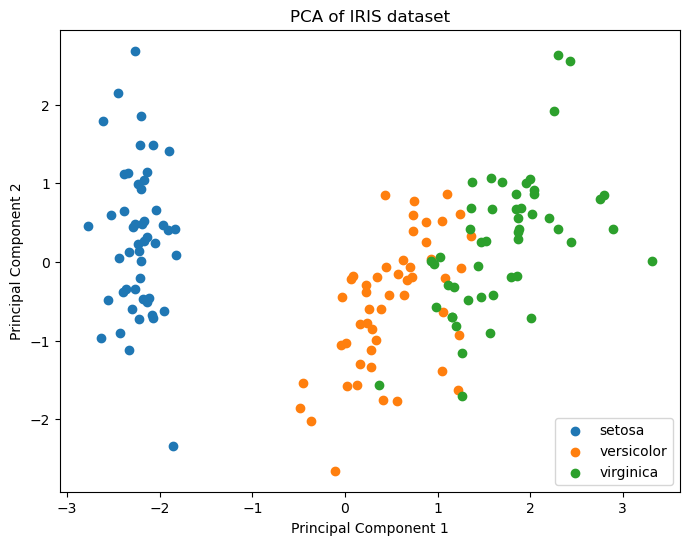

In [4]:
import matplotlib.pyplot as plt

# 繪製 PCA 降維後的資料
plt.figure(figsize=(8, 6))
for i, target_name in enumerate(iris.target_names):
    plt.scatter(y[targets == i, 0], y[targets == i, 1], label=target_name)

plt.title('PCA of IRIS dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

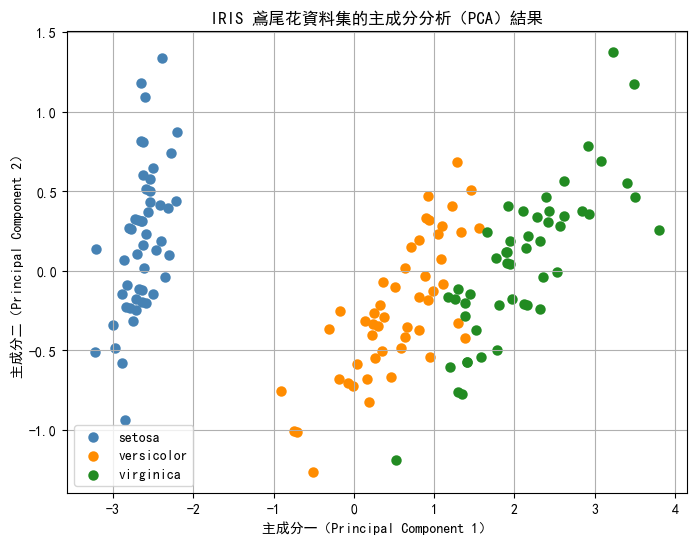

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib as mpl

# 设置matplotlib使用支持中文的字体
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题

# 讀取 IRIS 資料集
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 使用 PCA 進行降維（降到 2 維）
pca = PCA(n_components=2)
X_r = pca.fit_transform(X)

# 繪製結果圖
colors = ['steelblue', 'darkorange', 'forestgreen']
plt.figure(figsize=(8, 6))
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_r[y == i, 0], X_r[y == i, 1], color=color, lw=1.5, label=target_name)

plt.title('IRIS 鳶尾花資料集的主成分分析（PCA）結果')
plt.xlabel('主成分一（Principal Component 1）')
plt.ylabel('主成分二（Principal Component 2）')
plt.legend()
plt.grid(True)
plt.show()


測試集分類準確率：0.98


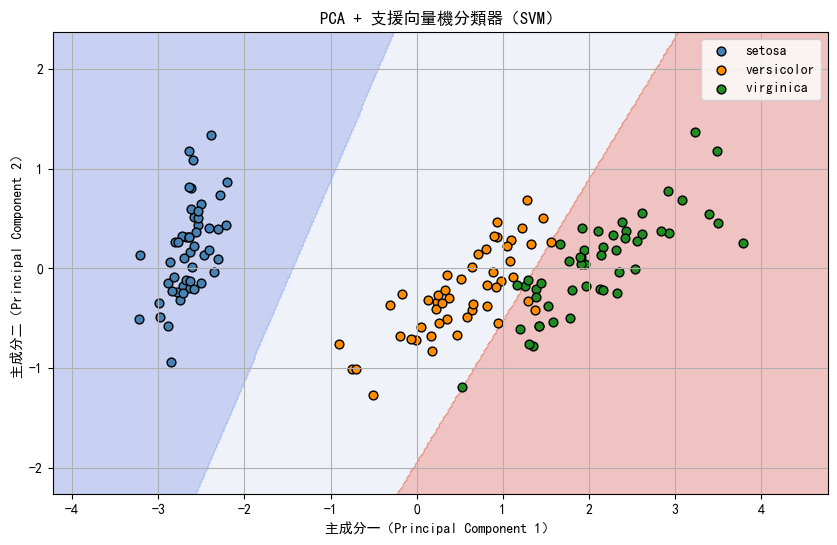

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib as mpl

# 设置matplotlib使用支持中文的字体
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
# 1. 讀取 IRIS 資料集
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. 使用 PCA 將資料降至 2 維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. 資料切分（訓練集與測試集）
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. 建立分類器（使用支援向量機）
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

# 5. 預測與準確率
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"測試集分類準確率：{accuracy:.2f}")

# 6. 繪製分類結果與決策邊界
colors = ['steelblue', 'darkorange', 'forestgreen']
h = .02  # 網格解析度

# 建立 meshgrid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 畫出決策邊界
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# 畫出實際點
for i, color, label in zip([0, 1, 2], colors, target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, label=label, edgecolor='k', s=40)

plt.title("PCA + 支援向量機分類器（SVM）")
plt.xlabel("主成分一（Principal Component 1）")
plt.ylabel("主成分二（Principal Component 2）")
plt.legend()
plt.grid(True)
plt.show()


✅ 核心策略一：改用原始特徵資料（不降維）
PCA 會壓縮資訊，雖然視覺化很好看，但對分類效果不一定是最優的。因此我們可以：

保留原始 4 維特徵

不進行 PCA，直接使用 SVM 或其他分類器

測試集分類準確率：0.98


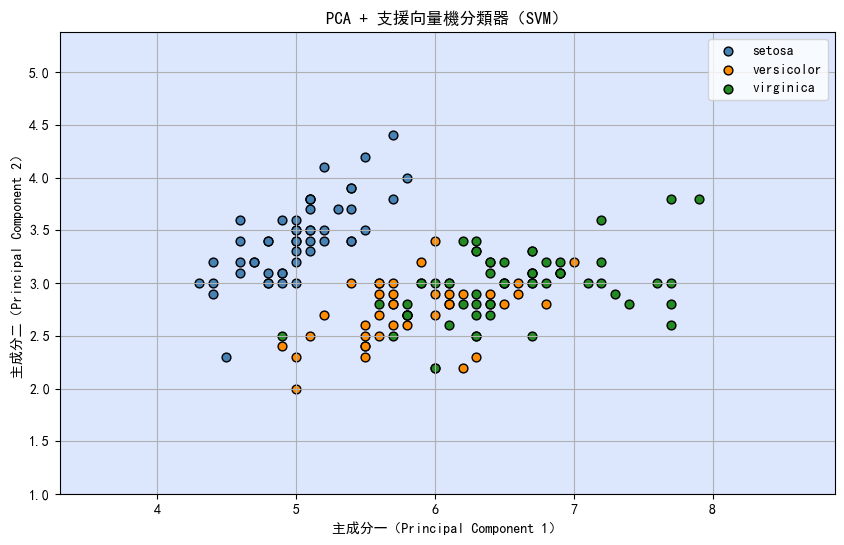

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib as mpl

# 设置matplotlib使用支持中文的字体
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
# 1. 讀取 IRIS 資料集
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. 使用 PCA 將資料降至 2 維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. 資料切分（訓練集與測試集）
## X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. 建立分類器（使用支援向量機）
## clf = SVC(kernel='linear')
# 改為使用 PCA 降維後的資料 X_pca
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

clf = SVC(kernel='rbf', C=1.0, gamma='scale')  # 使用 RBF 核心更強大
clf.fit(X_train, y_train)

# 5. 預測與準確率
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"測試集分類準確率：{accuracy:.2f}")

# 6. 繪製分類結果與決策邊界
colors = ['steelblue', 'darkorange', 'forestgreen']
h = .02  # 網格解析度

# 建立 meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 畫出決策邊界
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# 畫出實際點
for i, color, label in zip([0, 1, 2], colors, target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, label=label, edgecolor='k', s=40)

plt.title("PCA + 支援向量機分類器（SVM）")
plt.xlabel("主成分一（Principal Component 1）")
plt.ylabel("主成分二（Principal Component 2）")
plt.legend()
plt.grid(True)
plt.show()

✅ 核心策略二：使用非線性分類器（Kernel SVM）
如果你堅持用 PCA 降維後的資料，也可以考慮使用 非線性分類器，例如：

RBF 核心（Gaussian kernel）

Polynomial 核心

這些都能補強線性模型的限制，提升分類的彈性與表現力。

測試集分類準確率：1.00


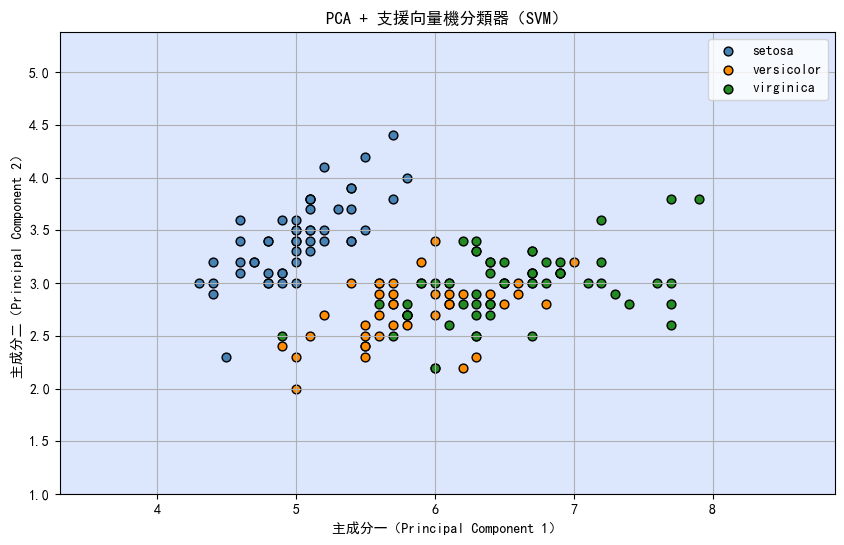

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib as mpl

# 设置matplotlib使用支持中文的字体
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
# 1. 讀取 IRIS 資料集
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. 使用 PCA 將資料降至 2 維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. 資料切分（訓練集與測試集）
## X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. 建立分類器（使用支援向量機）
## clf = SVC(kernel='linear')
# 改為使用 PCA 降維後的資料 X_pca
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# clf = SVC(kernel='rbf', C=1.0, gamma='scale')  # 使用 RBF 核心更強大
clf = SVC(kernel='rbf', gamma='auto')
clf.fit(X_train, y_train)

# 5. 預測與準確率
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"測試集分類準確率：{accuracy:.2f}")

# 6. 繪製分類結果與決策邊界
colors = ['steelblue', 'darkorange', 'forestgreen']
h = .02  # 網格解析度

# 建立 meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 畫出決策邊界
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# 畫出實際點
for i, color, label in zip([0, 1, 2], colors, target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, label=label, edgecolor='k', s=40)

plt.title("PCA + 支援向量機分類器（SVM）")
plt.xlabel("主成分一（Principal Component 1）")
plt.ylabel("主成分二（Principal Component 2）")
plt.legend()
plt.grid(True)
plt.show()

✅ 核心策略三：使用更多主成分（例如保留 95% 變異）
PCA 預設只保留前兩個主成分，但這可能無法保留足夠資訊。可使用：

測試集分類準確率：1.00


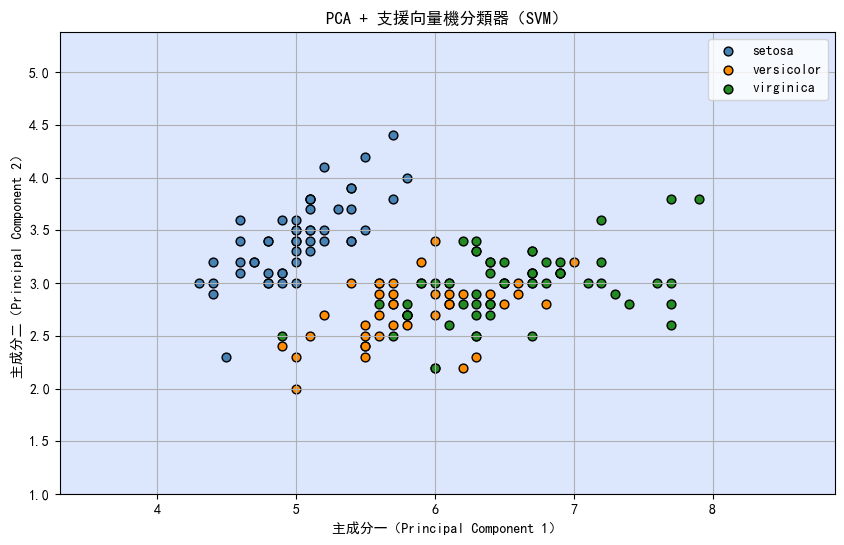

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib as mpl

# 设置matplotlib使用支持中文的字体
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
# 1. 讀取 IRIS 資料集
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. 使用 PCA 將資料降至 2 維
# pca = PCA(n_components=2)
# 保留足以涵蓋 95% 資訊的主成分
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

# 3. 資料切分（訓練集與測試集）
## X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. 建立分類器（使用支援向量機）
## clf = SVC(kernel='linear')
# 改為使用 PCA 降維後的資料 X_pca
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# clf = SVC(kernel='rbf', C=1.0, gamma='scale')  # 使用 RBF 核心更強大
clf = SVC(kernel='rbf', gamma='auto')
clf.fit(X_train, y_train)

# 5. 預測與準確率
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"測試集分類準確率：{accuracy:.2f}")

# 6. 繪製分類結果與決策邊界
colors = ['steelblue', 'darkorange', 'forestgreen']
h = .02  # 網格解析度

# 建立 meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 畫出決策邊界
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# 畫出實際點
for i, color, label in zip([0, 1, 2], colors, target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, label=label, edgecolor='k', s=40)

plt.title("PCA + 支援向量機分類器（SVM）")
plt.xlabel("主成分一（Principal Component 1）")
plt.ylabel("主成分二（Principal Component 2）")
plt.legend()
plt.grid(True)
plt.show()

✅ 核心策略四：嘗試其他分類器進行比較
可嘗試的包括：

K-Nearest Neighbors（KNN）

Random Forest

Logistic Regression

Gradient Boosting

測試集分類準確率：0.98


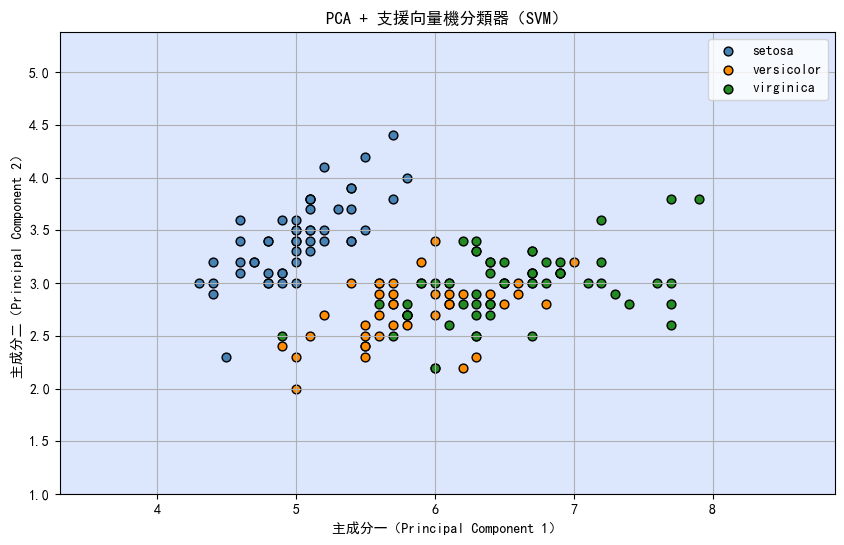

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib as mpl

# 设置matplotlib使用支持中文的字体
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
# 1. 讀取 IRIS 資料集
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. 使用 PCA 將資料降至 2 維
# pca = PCA(n_components=2)
# 保留足以涵蓋 95% 資訊的主成分
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

# 3. 資料切分（訓練集與測試集）
## X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. 建立分類器（使用支援向量機）
## clf = SVC(kernel='linear')
# 改為使用 PCA 降維後的資料 X_pca
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# clf = SVC(kernel='rbf', C=1.0, gamma='scale')  # 使用 RBF 核心更強大
# clf = SVC(kernel='rbf', gamma='auto')
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. 預測與準確率
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"測試集分類準確率：{accuracy:.2f}")

# 6. 繪製分類結果與決策邊界
colors = ['steelblue', 'darkorange', 'forestgreen']
h = .02  # 網格解析度

# 建立 meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 畫出決策邊界
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# 畫出實際點
for i, color, label in zip([0, 1, 2], colors, target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], color=color, label=label, edgecolor='k', s=40)

plt.title("PCA + 支援向量機分類器（SVM）")
plt.xlabel("主成分一（Principal Component 1）")
plt.ylabel("主成分二（Principal Component 2）")
plt.legend()
plt.grid(True)
plt.show()

✅ 核心策略五：混淆矩陣分析錯誤來源
你可以視覺化混淆矩陣，檢查哪兩類最常被混淆，然後考慮做特徵選擇或進一步資料清洗。

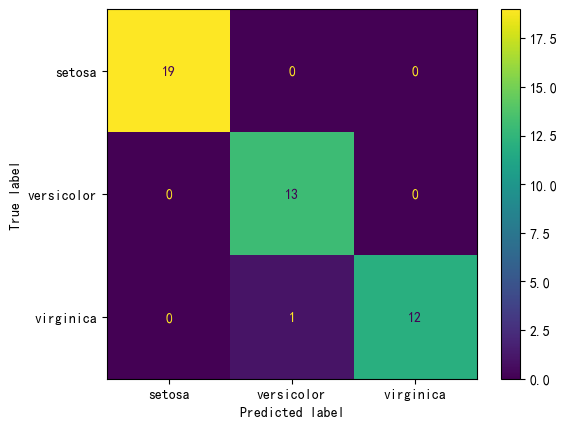

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.show()

---

## 💡 結論

| 策略 | 適用時機 | 優點 |
|------|-----------|------|
| 使用原始特徵 | 分類為主要任務時 | 保留所有資訊 |
| 改用 RBF 或多項式核心 | 分類邊界非線性時 | 提升彈性 |
| 保留更多主成分 | 想降維又不想損失太多精度時 | 兼顧視覺化與準確率 |
| 嘗試其他分類器 | 對比分析性能 | 發現最適合模型 |
| 混淆矩陣 | 排查錯誤來源 | 針對性優化模型 |

---